# 📊 EDA — Análise Exploratória: Risco de Crédito

> **Objetivo**: Entender a estrutura dos dados, identificar padrões preditivos e guiar as decisões de feature engineering e modelagem.

---

## Sumário
1. [Importação de bibliotecas](#1)
2. [Carregamento dos dados](#2)
3. [Visão geral do dataset](#3)
4. [Distribuição da variável alvo](#4)
5. [Análise de distribuição das variáveis](#5)
6. [Identificação de outliers](#6)
7. [Avaliação da correlação entre as variáveis](#7)
8. [Relação das variáveis explicativas x alvo](#8)
9. [Feature insights](#9)

## 1. Importação de bibliotecas <a id='1'></a>

Vamos importar as bibliotecas necessárias para realizar a leitura e análise gráfica dos dados, além de realizar a definição do tema para os gráficos.

In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(
    style="darkgrid",
    palette="deep",
    font_scale=1.1
)

plt.rcParams["figure.figsize"] = (10, 6)

## 2. Carregamento dos dados <a id='2'></a>

Vamos realizar o carregamento dos dados brutos, que servirão como base para a análise e serão transformados posteriormente com o intuito de servirem de fonte para um modelo de ML.

In [27]:
lending_data = pd.read_csv('../data/raw/lending_data.csv')

## 3. Visão geral do dataset <a id='3'></a>

Vamos visualizar os dados e identificar quais informações temos à disposição.

In [28]:
lending_data

,loan_size,interest_rate,borrower_income,debt_to_income,num_of_accounts,derogatory_marks,total_debt,loan_status
0,10700.0,7.672,52800,0.431818,5,1,22800,0
1,8400.0,6.692,43600,0.311927,3,0,13600,0
2,9000.0,6.963,46100,0.349241,3,0,16100,0
3,10700.0,7.664,52700,0.430740,5,1,22700,0
4,10800.0,7.698,53000,0.433962,5,1,23000,0
...,...,...,...,...,...,...,...,...
77531,19100.0,11.261,86600,0.653580,12,2,56600,1
77532,17700.0,10.662,80900,0.629172,11,2,50900,1
77533,17600.0,10.595,80300,0.626401,11,2,50300,1
77534,16300.0,10.068,75300,0.601594,10,2,45300,1


In [29]:
lending_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77536 entries, 0 to 77535
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   loan_size         77536 non-null  float64
 1   interest_rate     77536 non-null  float64
 2   borrower_income   77536 non-null  int64  
 3   debt_to_income    77536 non-null  float64
 4   num_of_accounts   77536 non-null  int64  
 5   derogatory_marks  77536 non-null  int64  
 6   total_debt        77536 non-null  int64  
 7   loan_status       77536 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 4.7 MB


Identificamos que o conjunto de dados é formado por **8 colunas**, com o total de **77536 registros**, sem apresentar nenhuma informação nula.

Todos os dados são numéricos, o que facilita transformações posteriores e interpretação dos modelos de ML.

A partir de um dicionário de dados, temos acesso a explicação de cada uma das variáveis:

| Variável             | Tipo         | Descrição                                         |
| -------------------- | ------------ | ------------------------------------------------- |
| **loan_size**        | numérica        | Valor do empréstimo concedido                     |
| **interest_rate**    | numérica        | Taxa de juros aplicada ao empréstimo              |
| **borrower_income**  | numérica        | Renda do cliente                                  |
| **debt_to_income**   | numérica        | Relação dívida/renda (DTI)                        |
| **num_of_accounts**  | numérica          | Número de contas/linhas de crédito                | 
| **derogatory_marks** | numérica          | Registros negativos (ex: inadimplência, atrasos)  |
| **total_debt**       | numérica          | Dívida total do cliente                           |
| **loan_status**      | numérica (target) | Status do empréstimo (0 = pago, 1 = inadimplente) |

O nosso problema em questão, trata de um problema de classificação binária (2 classes), com a variável alvo sendo o `loan_status`.


Podemos realizar uma separação da variável alvo e das variáveis explicativas, com a finalidade de facilitar análises futuras.

In [64]:
y = lending_data[['loan_status']]
x = lending_data.drop('loan_status', axis = 1)

## 4. Distribuição da variável alvo <a id='4'></a>

Vamos analisar a distribuição da variável alvo, avaliando o percentual de valores de cada uma das classes.

In [57]:
print("Percentual de dados do risco de crédito (loan_status):")
print(f"Saudável (0): {round(lending_data["loan_status"].value_counts(normalize=True)[0]*100,2)}%")
print(f"Risco de crédito alto (1): {round(lending_data["loan_status"].value_counts(normalize=True)[1]*100,2)}%")

Percentual de dados do risco de crédito (loan_status):
Saudável (0): 96.78%
Risco de crédito alto (1): 3.22%


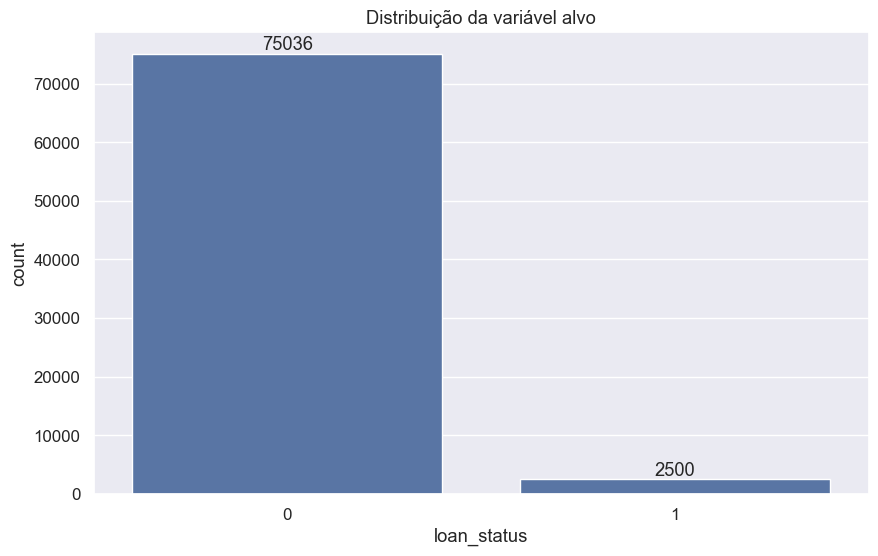

In [59]:
ax = sns.countplot(x="loan_status", data=lending_data)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='edge')
plt.title("Distribuição da variável alvo")
plt.show()

#### ⚠️

A partir do gráfico de contagem e análise percentual, podemos perceber que a variável alvo `loan_status` é extremamente desbalanceada, com cerca de apenas 3% dos valores sendo do grupo de risco. Isso pode impactar no entendimento do modelo de ML que será treinado posteriormente, e teremos que adotar estratégias para que isso não prejudique o treinamento.

Para o nosso problema de classificação, considerando o desbalanceamento da variável alvo e também interpretando o risco de crédito, não poderemos avaliar simplesmente a taxa de acerto geral do modelo (acurácia). Devemos nos valer dos seguintes tipos de erro e impactos que podem causar ao problema:

| Situação                           | Tipo de erro   | Impacto                                |
| ---------------------------------- | -------------- | -------------------------------------- |
| Cliente bom classificado como ruim | Falso Positivo | perde dinheiro (cliente bom rejeitado) |
| Cliente ruim classificado como bom | Falso Negativo | perde MUITO dinheiro 💸                |

❗ Portanto, o erro do tipo Falso Negativo é o pior cenário, no qual um cliente que é um devedor é classificado como um bom cliente. Temos que evitar ao máximo esse tipo de erro.

A métrica que melhor identifica esse tipo de erro é o Recall da classe 1. Portanto temos que focar em maximizar essa métrica para o nosso modelo. Como complemento, também podemos focar em manter níveis satisfatórios para as métricas abaixo, a fim de manter um equilíbrio entre a classificação das classes:

- Precision
- F1-score
- ROC AUC



## 5. Análise de distribuição das variáveis <a id='5'></a>

Vamos avaliar agora a distribuição de dados das variáveis explicativas, que serão usadas para obter a classificação do nosso modelo.

In [80]:
x.describe()

,loan_size,interest_rate,borrower_income,debt_to_income,num_of_accounts,derogatory_marks,total_debt,loan_income_ratio
count,77536.000000,77536.000000,77536.000000,77536.000000,77536.000000,77536.000000,77536.000000,77536.000000
mean,9805.562577,7.292333,49221.949804,0.377318,3.826610,0.392308,19221.949804,0.198111
std,2093.223153,0.889495,8371.635077,0.081519,1.904426,0.582086,8371.635077,0.006824
min,5000.000000,5.250000,30000.000000,0.000000,0.000000,0.000000,0.000000,0.166113
25%,8700.000000,6.825000,44800.000000,0.330357,3.000000,0.000000,14800.000000,0.194196
50%,9500.000000,7.172000,48100.000000,0.376299,4.000000,0.000000,18100.000000,0.197938
75%,10400.000000,7.528000,51400.000000,0.416342,4.000000,1.000000,21400.000000,0.201536
max,23800.000000,13.235000,105200.000000,0.714829,16.000000,3.000000,75200.000000,0.226236


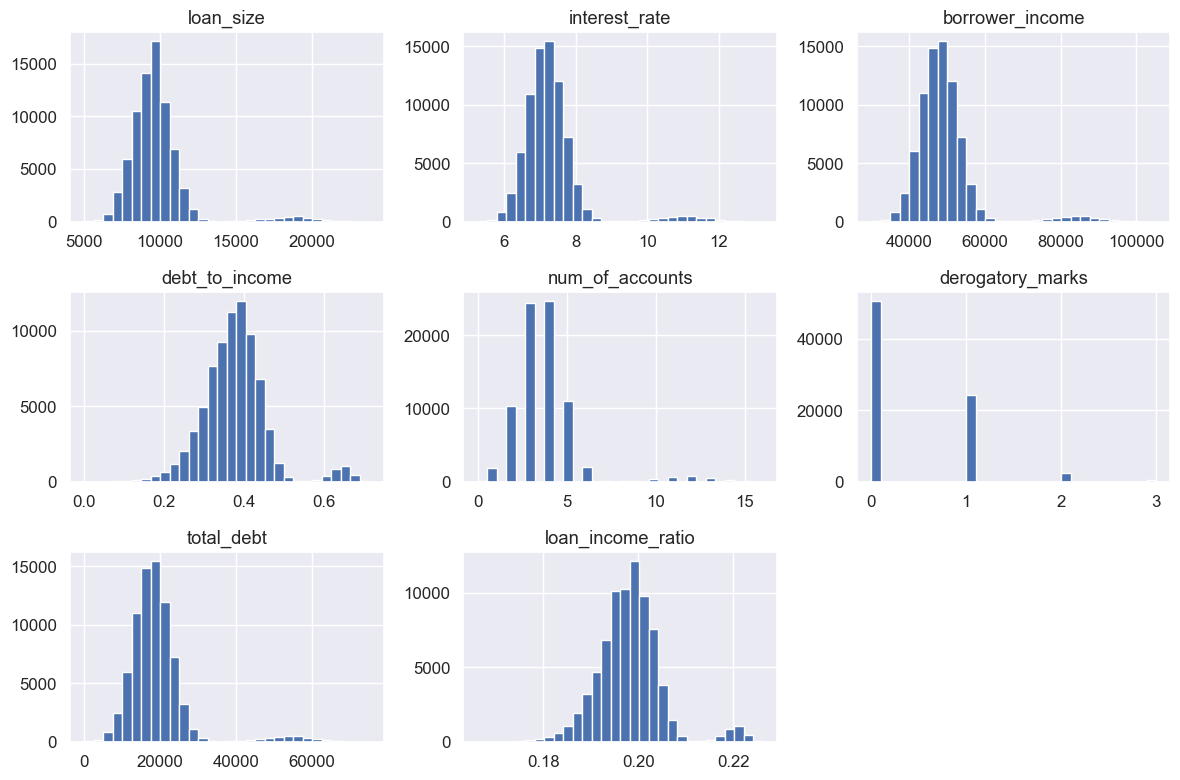

In [67]:
x.hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

As variáveis apresentam escalas diferentes, algumas variando na escala das unidades, outras dezenas e outras em milhares.

A maior parte das variáveis apresentam comportamento de distribuição centrado em uma média, com variações em torno dessa média, com um padrão observável de um comportamento em formato de sino, semelhante a uma distribuição normal. Porém, apenas com testes estatísticos para comprovar esse comportamento.

É possível notar que existe em alguns gráficos, distribuições menores centradas em outras médias, configurando uma combinação de distribuições normais em uma mesma variável. O que leva a acreditar que pode haver grupos distintos em uma mesma variável. Podemos analisar esse comportamento posteriormente.

As variáveis como `num_of_accounts` e `derogatory_marks` se configuram como variáveis de contagem, com valores iniciando com 0 e variação em unidades.

Vamos continuar a análise com a identificação de prováveis outliers e avaliação da distribuição para diferentes categorias da variável alvo.

❗Como as variáveis apresentam escalas muito distintas, é uma boa ideia realizar uma transformação nos dados, para que fiquem normalizados. Podemos usar a normalização de minímos e máximos ou a padronização por z-scores.

## 6. Identificação de outliers <a id='6'></a>

Para obter um modelo de classificação com qualidade, podemos avaliar se existe a presença de outliers nas variáveis explicativas. Isso pode auxiliar a realização de transformações nos dados que auxiliam o modelo a entender melhor o comportamento da maior parte dos dados.

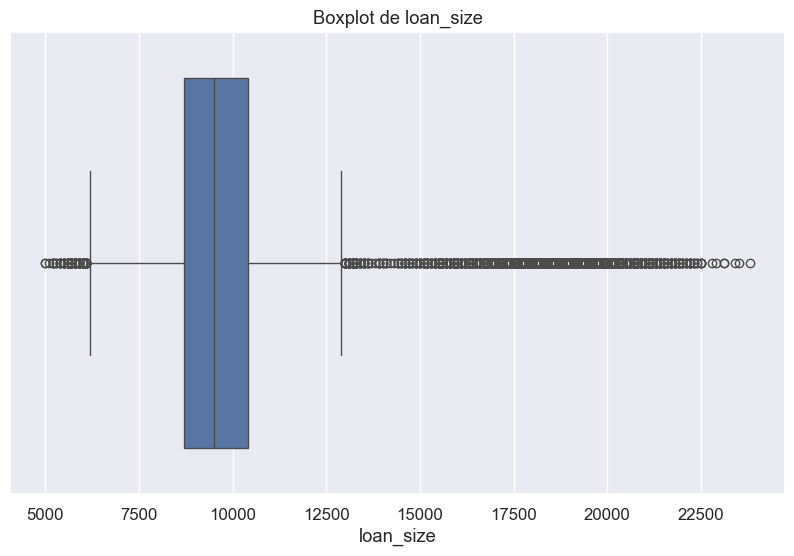

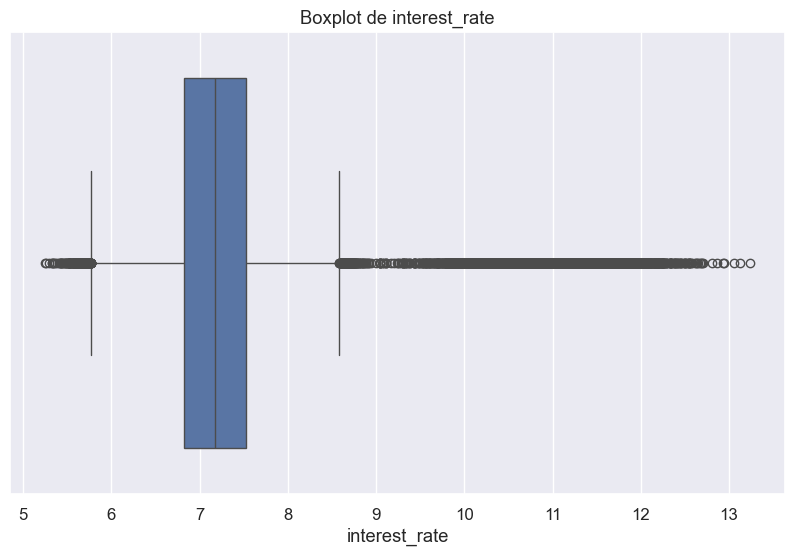

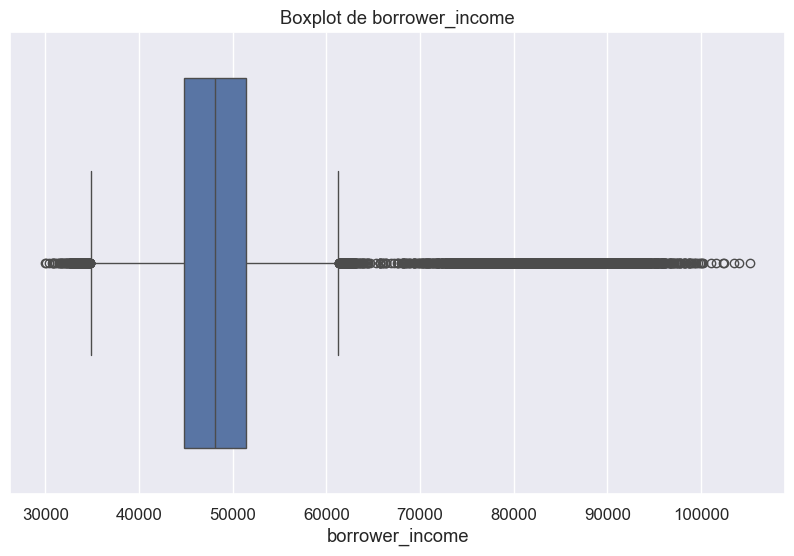

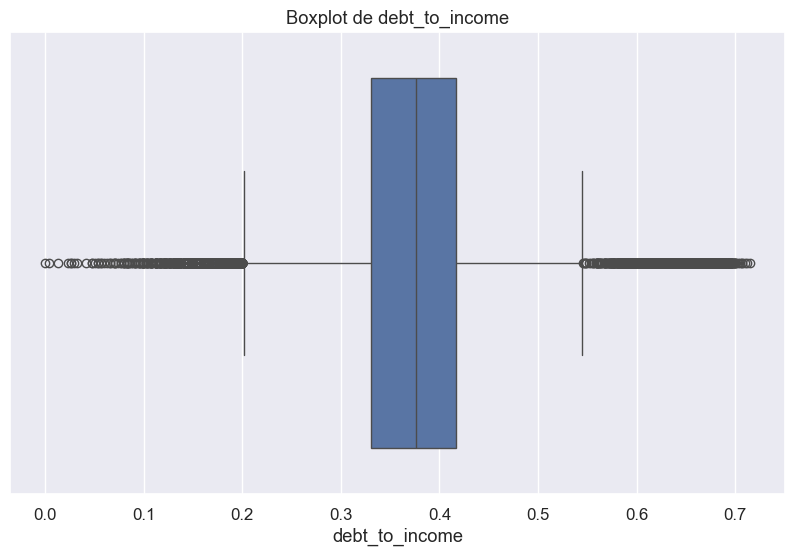

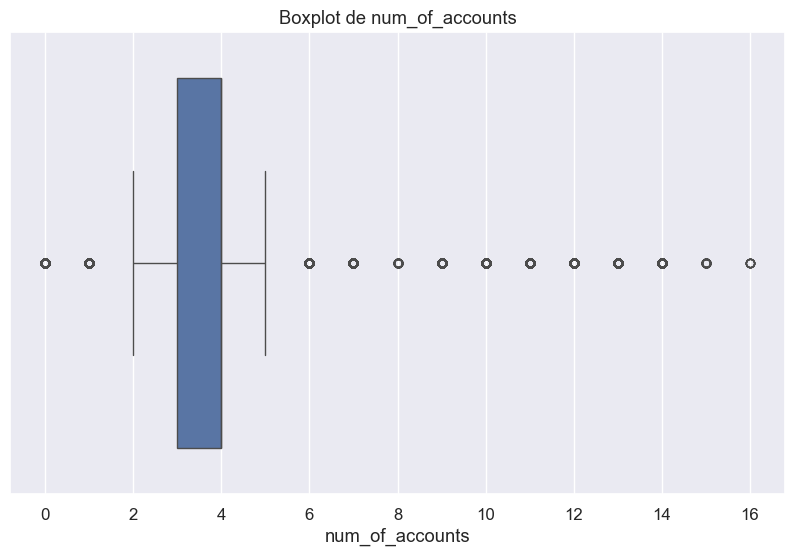

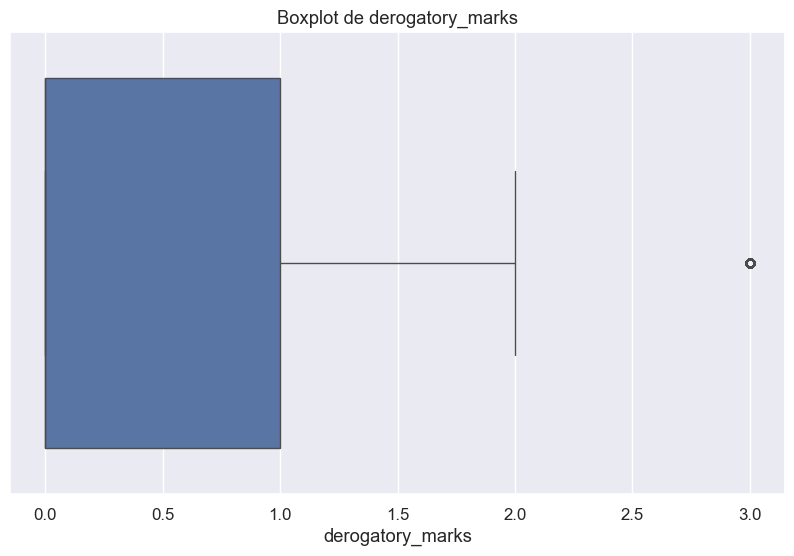

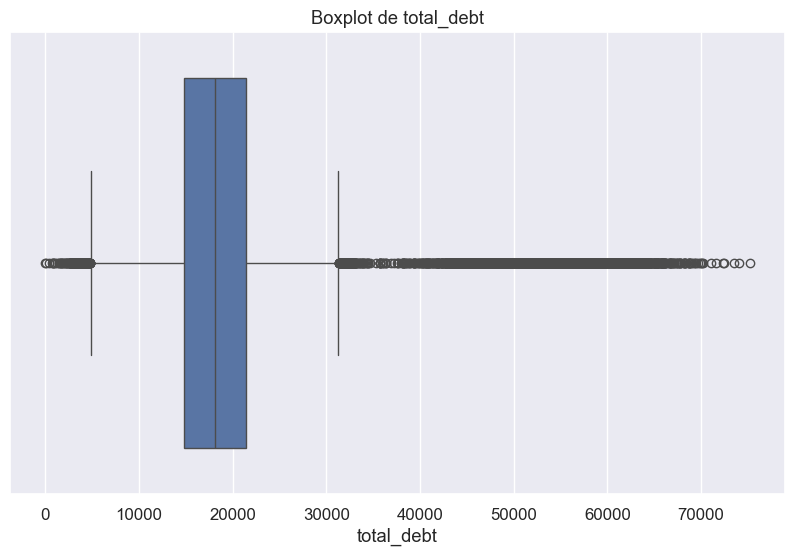

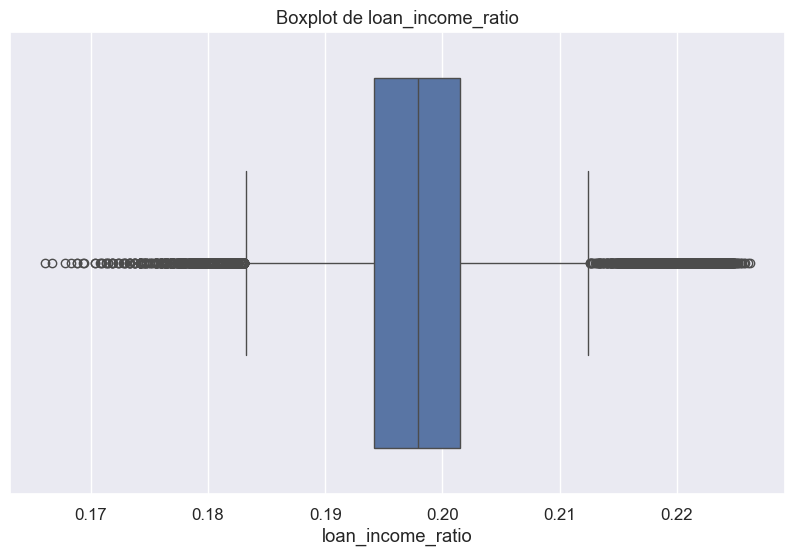

In [71]:
for col in x.columns:
    sns.boxplot(x=lending_data[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

A partir da visualização dos boxplots e também dos histogramas na seção anterior, podemos identificar que, apesar de existirem valores fora da concentração maior de dados, não há valores que fogem muito do padrão geral dos dados. Apenas existem distribuições com caudas alongadas, tanto à esquerda, quanto à direita da média.

As transformações de escala podem ajudar a reduzir esse comportamento e evitar que prejudiquem o entendimento do modelo de classificação. Portanto, não vamos realizar nenhuma remoção de dados ou tratamento especial para essa etapa.

## 7. Avaliação da correlação entre as variáveis <a id='7'></a>

Vamos agora avaliar a correlação entre as variáveis da nossa base de dados, a fim de detectar se as variáveis são relevantes para a identificação da variável alvo e também detectar possíveis multicolinearidade das variáveis explicativas.

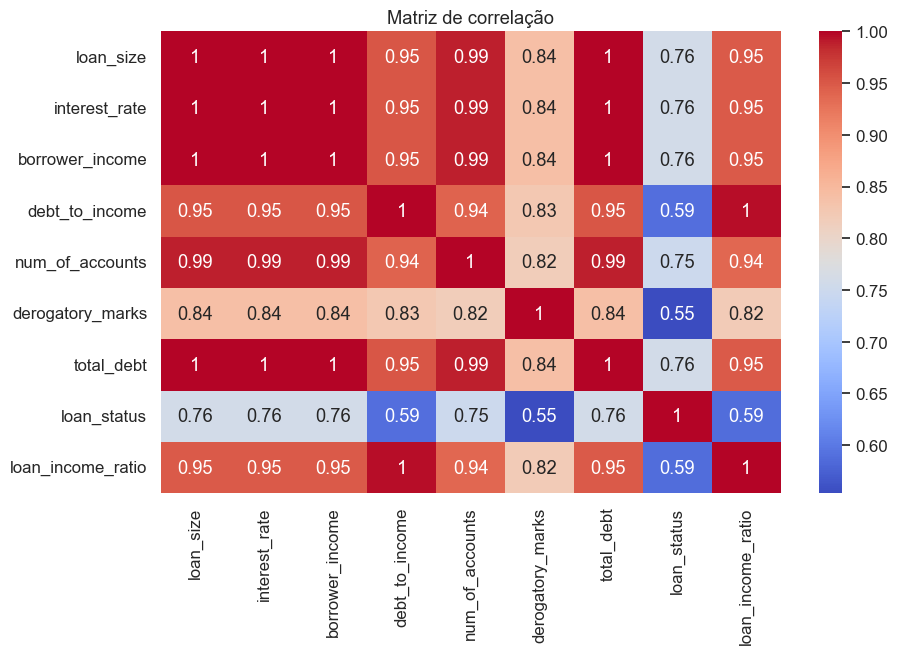

In [72]:
sns.heatmap(lending_data.corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de correlação")
plt.show()

Com uma simples matriz de correlação, já podemos identificar que as variáveis `loan_size`, `interest_rate`, `borrower_income` e `total_debt` possuem correlação perfeita (1). Isso indica que essas variáveis têm o mesmo comportamento e podemos utilizar apenas uma delas em nosso modelo de ML. Utilizar variáveis que explicam a mesma coisa podem impactar negativamente nosso modelo, além de utilizar processamento desnecessário no treinamento e previsão.

⚠️ Devemos remover essas variáveis e manter apenas uma delas.

---

Em uma segunda análise, se avaliarmos a variável alvo (`loan_status`) em relação às variáveis explicativas, podemos perceber que há uma correlação positiva e alta, que irá auxiliar beneficamente o nosso modelo de classificação.

## 8. Relação das variáveis explicativas x variável alvo <a id='8'></a>

Vamos analisar agora se existe alguma diferença no comportamento geral dos dados quando segmentamos os registros com base nas categorias da variável alvo. Vamos utilizar histogramas e boxplots para visualizar a distribuição separada por `loan_status`.

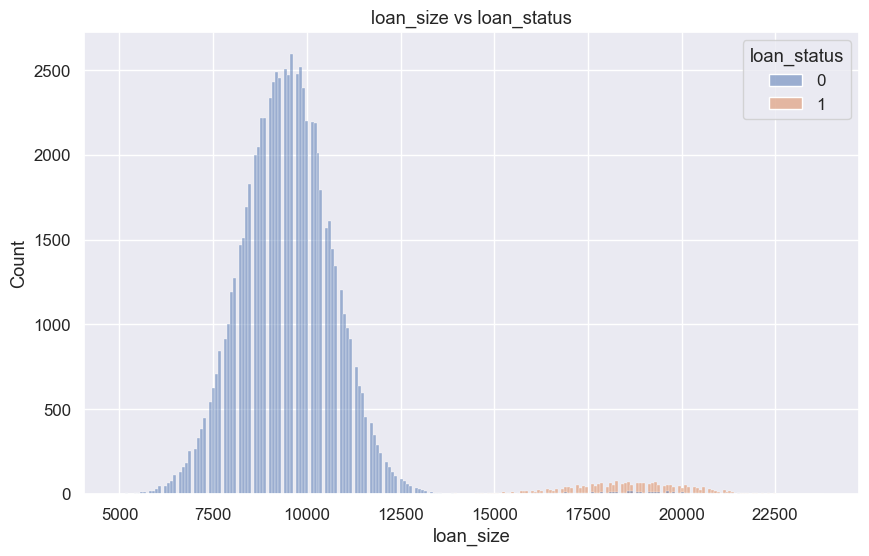

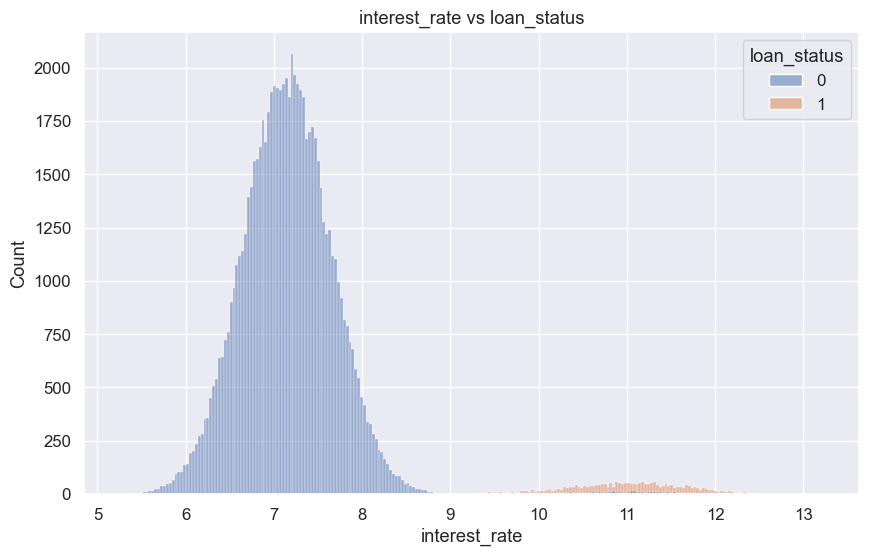

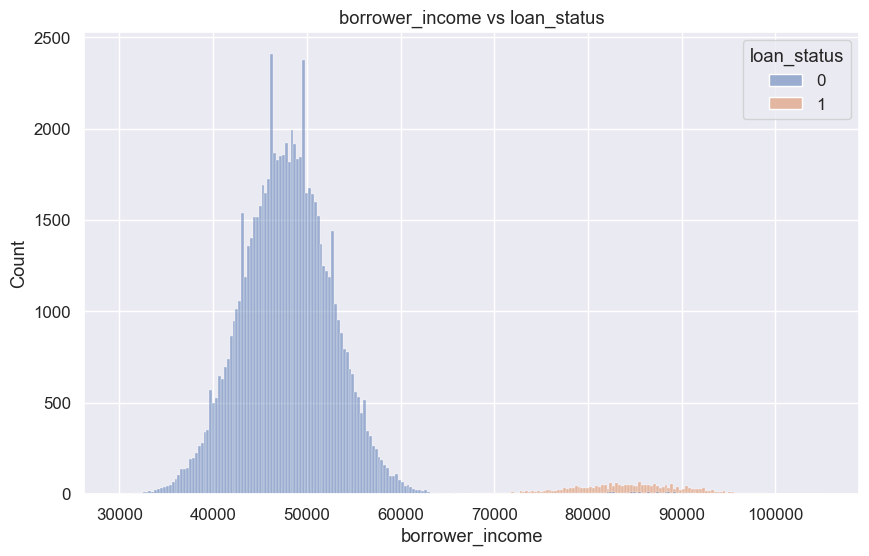

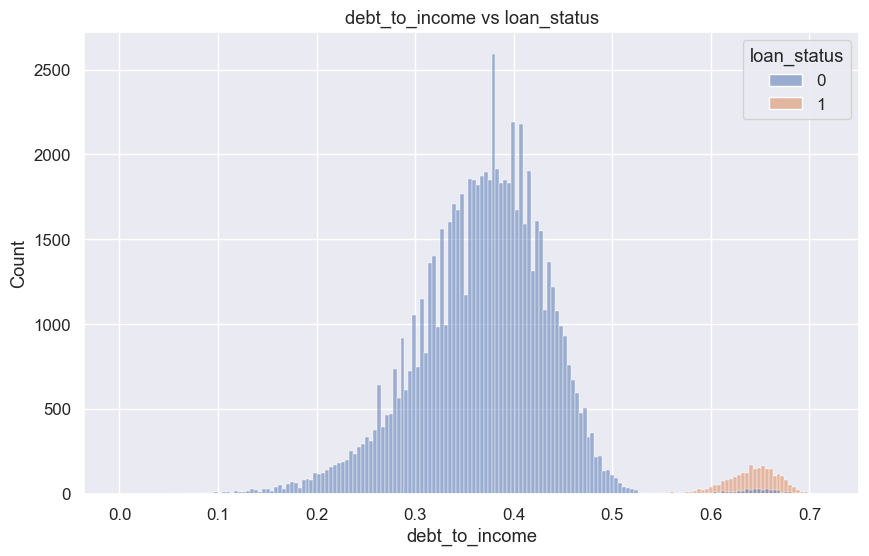

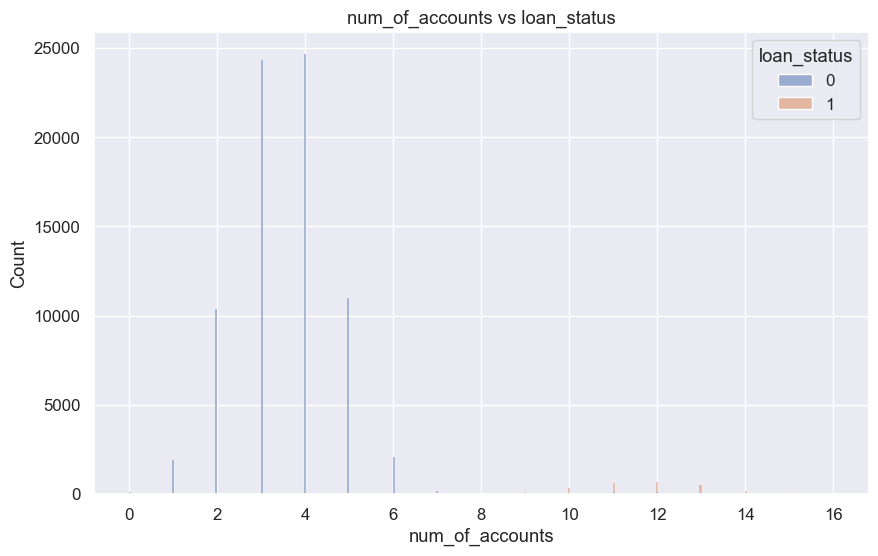

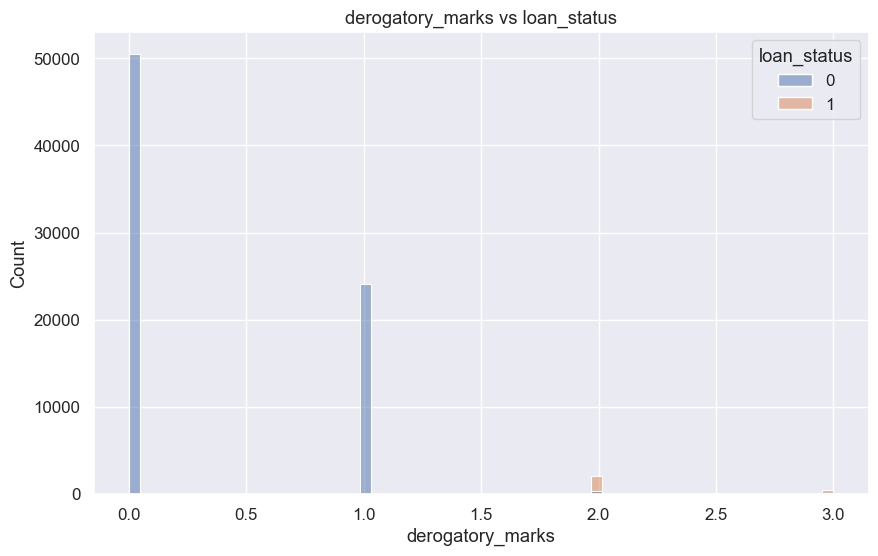

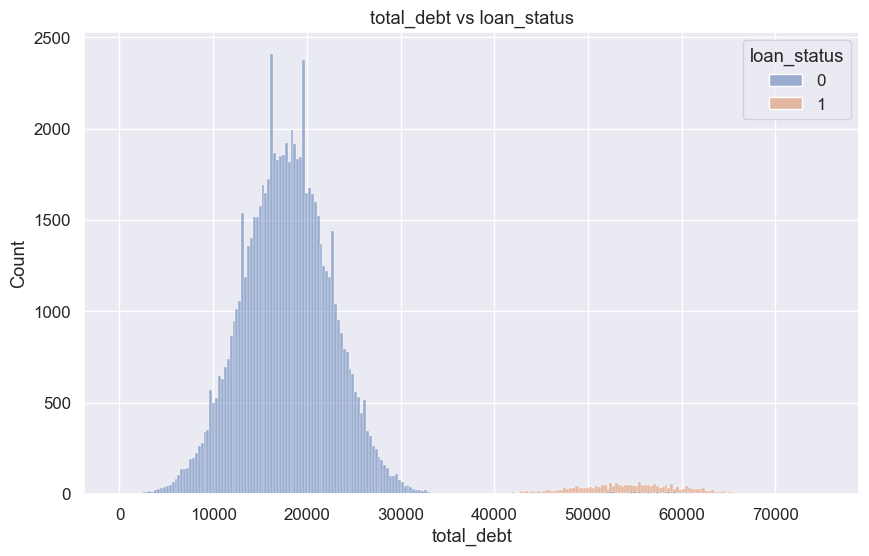

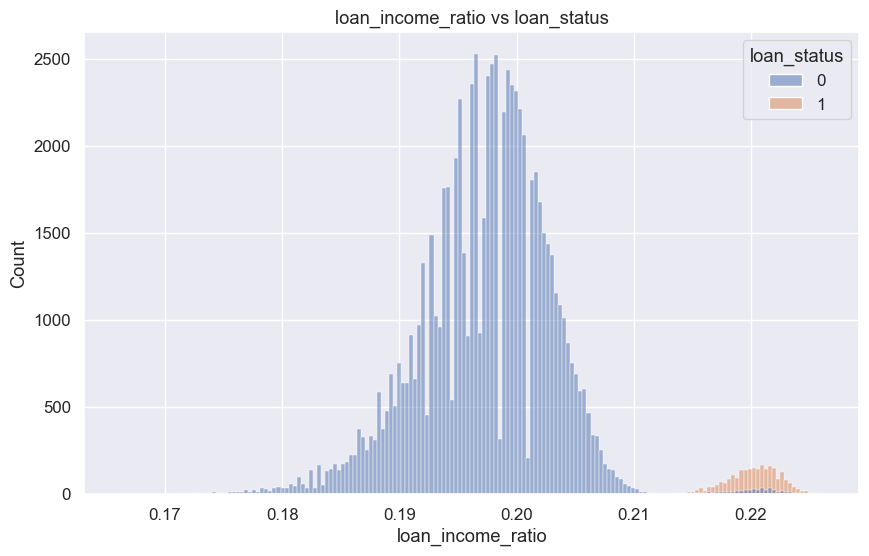

In [74]:
for col in lending_data.columns:
    if col != "loan_status":
        sns.histplot(x=col, data=lending_data, hue='loan_status')
        plt.title(f"{col} vs loan_status")
        plt.show()

Com base nos histogramas, podemos perceber que os registros que estão na classe 1, referente ao grupo crítico, apresenta média diferente do restante dos dados, sempre com média acima do habitual. Certamente esse comportamento será comprovado a partir de boxplots e tabelas de médias, uma vez que a visualização é bem nítida.

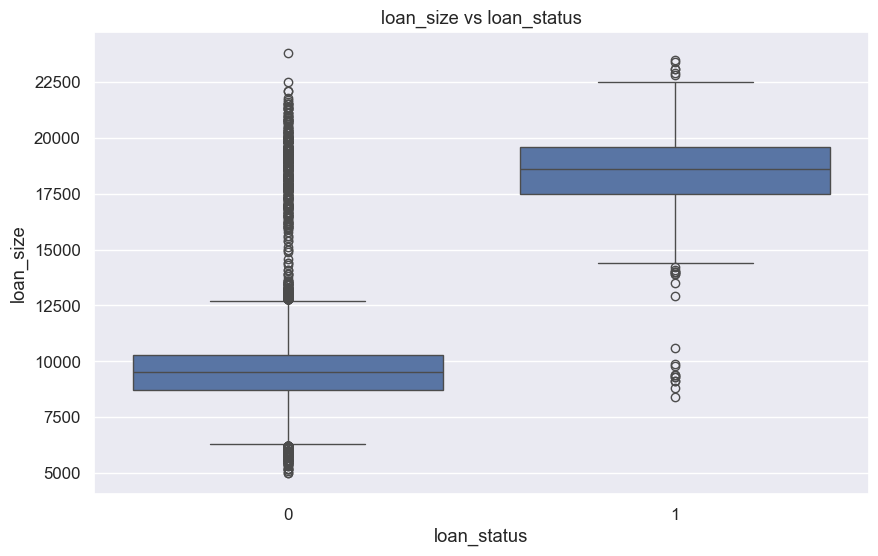

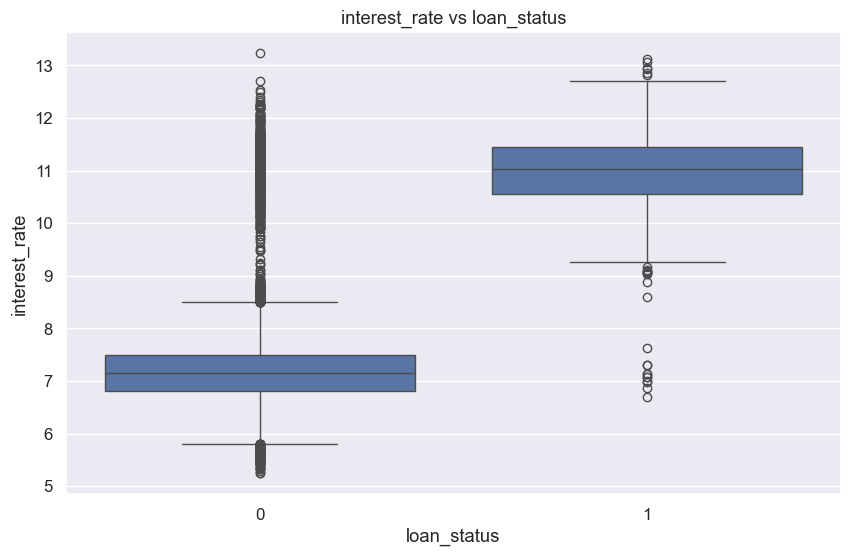

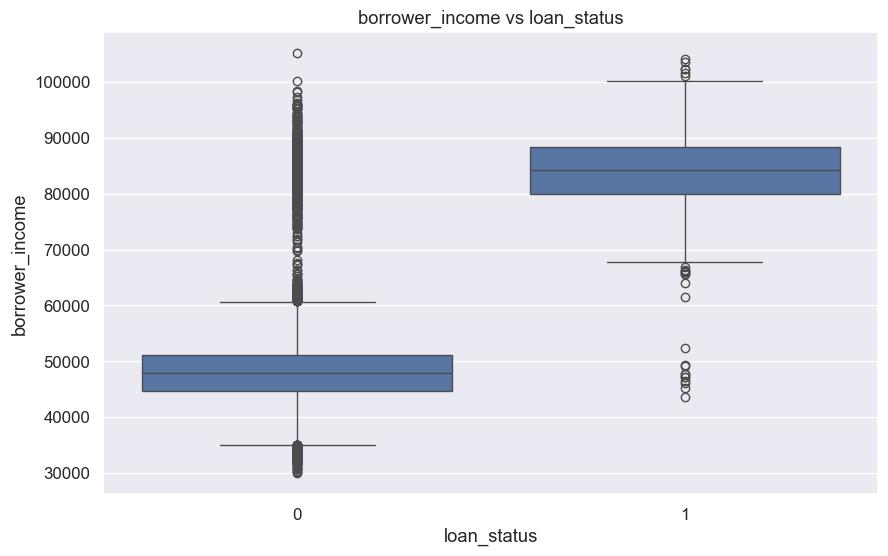

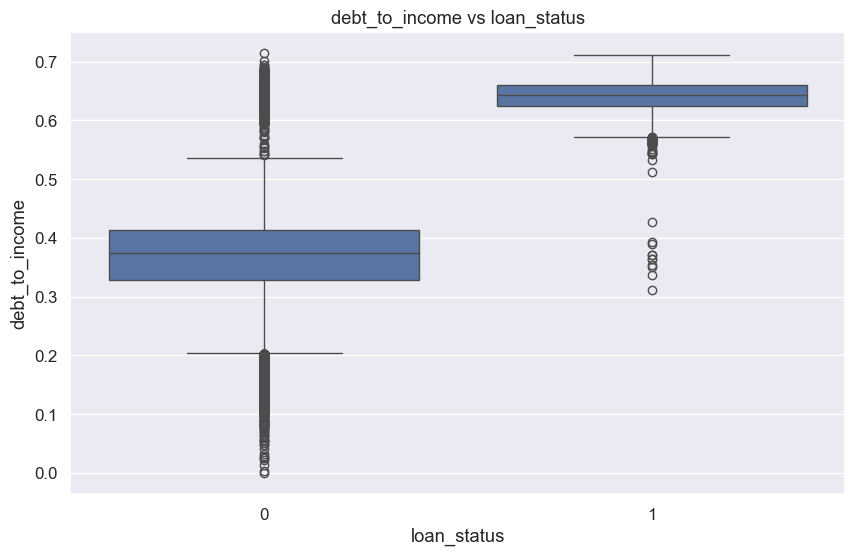

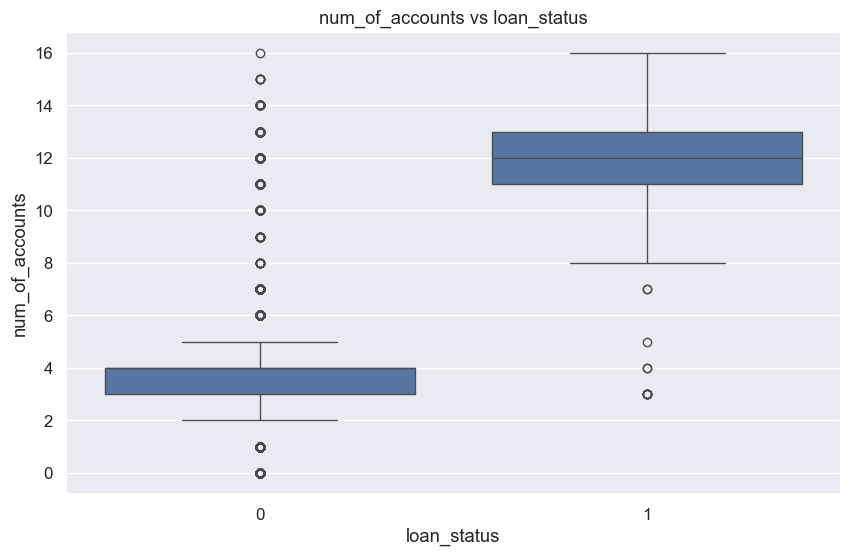

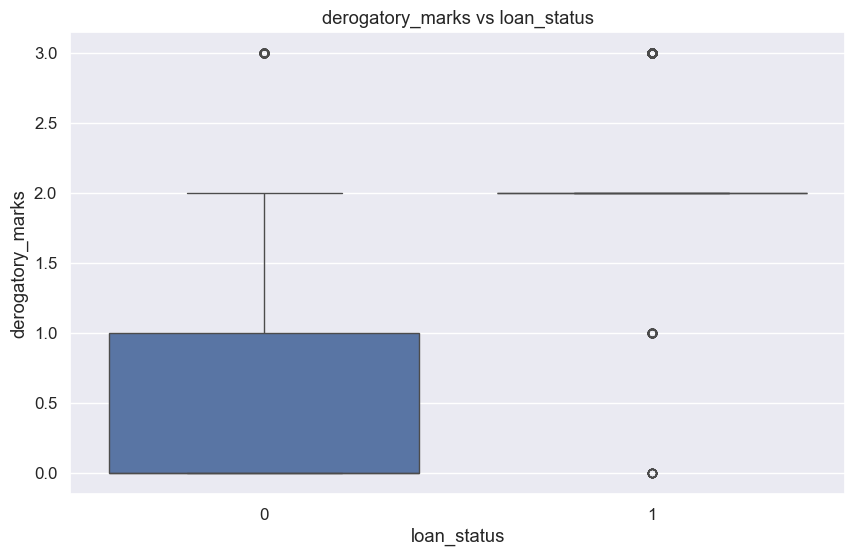

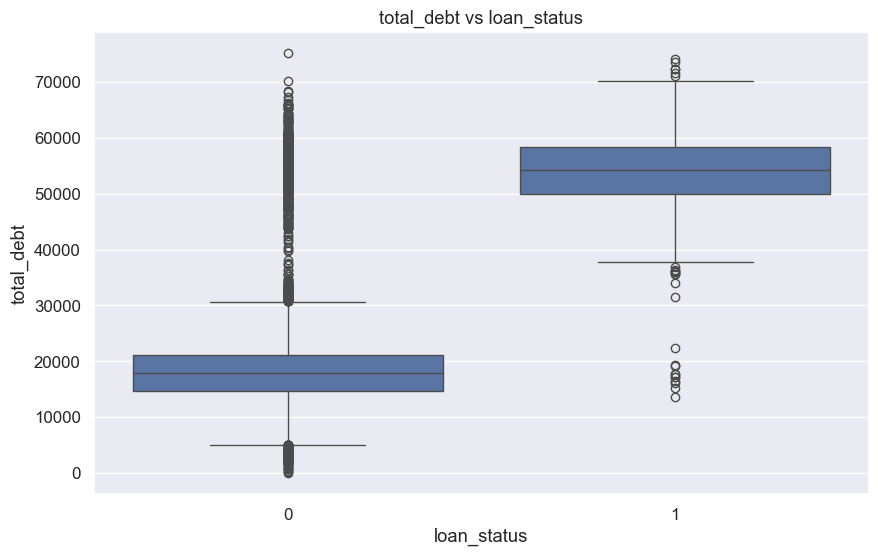

In [48]:
for col in lending_data.columns:
    if col != "loan_status":
        sns.boxplot(x="loan_status", y=col, data=lending_data)
        plt.title(f"{col} vs loan_status")
        plt.show()

In [49]:
lending_data.groupby("loan_status").mean()

,loan_size,interest_rate,borrower_income,debt_to_income,num_of_accounts,derogatory_marks,total_debt
loan_status,,,,,,,
0,9515.627166,7.169118,48062.314089,0.368549,3.565968,0.333533,18062.314089
1,18507.800000,10.990529,84027.720000,0.640501,11.649600,2.156400,54027.720000


In [79]:
mean_df = lending_data.groupby("loan_status").mean()
std_df = lending_data.groupby("loan_status").std()

for col in lending_data.columns:
    if col != "loan_status":
        mean_0 = mean_df.loc[0, col]
        mean_1 = mean_df.loc[1, col]

        std_0 = std_df.loc[0, col]
        std_1 = std_df.loc[1, col]

        diff = mean_1 - mean_0
        diff_pct = (diff / mean_0) * 100

        # sinal vs ruído (efeito)
        pooled_std = (std_0 + std_1) / 2
        effect_size = diff / pooled_std if pooled_std != 0 else 0

        interpretation = (
            "diferença entre as médias forte"
            if abs(effect_size) > 0.8
            else "diferença entre as médias moderada"
            if abs(effect_size) > 0.3
            else "diferença entre as médias fraca"
        )

        print(
            f"{col}\n"
            f"Médias: Média Grupo de risco = {mean_1:.2f} | Média grupo saudável = {mean_0:.2f}\n"
            f"Média do grupo de risco {abs(diff_pct):.1f}% {'maior' if diff > 0 else 'menor'}\n"
            f"Desvio padrão: Desvio padrão do grupo de risco = {std_1:.2f} | Desvio padrão do grupo saudável = {std_0:.2f}\n"
            f"Interpretação: {interpretation}\n"
            f"------------------------------"
        )

loan_size
Médias: Média Grupo de risco = 18507.80 | Média grupo saudável = 9515.63
Média do grupo de risco 94.5% maior
Desvio padrão: Desvio padrão do grupo de risco = 1649.81 | Desvio padrão do grupo saudável = 1352.68
Interpretação: diferença entre as médias forte
------------------------------
interest_rate
Médias: Média Grupo de risco = 10.99 | Média grupo saudável = 7.17
Média do grupo de risco 53.3% maior
Desvio padrão: Desvio padrão do grupo de risco = 0.70 | Desvio padrão do grupo saudável = 0.57
Interpretação: diferença entre as médias forte
------------------------------
borrower_income
Médias: Média Grupo de risco = 84027.72 | Média grupo saudável = 48062.31
Média do grupo de risco 74.8% maior
Desvio padrão: Desvio padrão do grupo de risco = 6598.06 | Desvio padrão do grupo saudável = 5409.45
Interpretação: diferença entre as médias forte
------------------------------
debt_to_income
Médias: Média Grupo de risco = 0.64 | Média grupo saudável = 0.37
Média do grupo de risco 73

A partir dos boxplots e também de uma análise simples de médias, podemos verificar que os grupos de registros são altamente separáveis. Isso facilitará o entendimento dos dados a partir de um modelo de classificação.

## 9. Feature insights <a id='9'></a>

A partir da exploração dos dados, extraímos insights muito relevantes a respeito da base de dados e servirá de apoio para a tomada de decisão de transformações nos dados, escolha de métricas relevantes e seleção de features.

Os insights mais relevantes extraídos nessa etapa foram:

- Variável alvo extremamente desbalanceada: Necessário transformações nos dados e escolha de modelos adequados para a tarefa de classificação.
- Variáveis com escalas diferentes: Necessário realizar transformações na escala das variáveis como a normalização de mínimos e máximos ou padronização por z-scores para manter todas em uma mesma escala.
- Recall da classe 1 como métrica de classificação mais relevante: Por se tratar de um modelo de risco de crédito, os erros relacionados aos Falsos negativos são muito impactantes, gerando prejuízos maiores que os erros de Falsos positivos. Se levarmos em conta o universo de todos os reais mau pagadores, o modelo não pode classificar muitas pessoas desse grupo como bons pagadores.
- Variáveis explicativas com correlação perfeita: Algumas variáveis explicativas apresentam multicolinearidade. Devemos selecionar apenas uma dessas variáveis.
